# [LAB 13] 6. Auto ARIMA

ARIMA 분석에 대해 자동으로 수행하는 모듈

## #01. 작업준비

### [1] 패키지 가져오기

> `pmdarima` 패키지의 설치가 필요하다

In [1]:
from hossam import *

from matplotlib import pyplot as plt
from matplotlib import dates
import seaborn as sb
import numpy as np

from pandas import DatetimeIndex, DataFrame
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error

### [2] 데이터 가져오기

In [2]:
origin = load_data("air_passengers")
origin.head()

어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


#### DateTimeIndex 설정

In [3]:
df1 = origin.set_index("Month")
df1 = df1.asfreq("MS")
df1.index = DatetimeIndex(df1.index)
df1.sort_index(inplace=True)
df1.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


### [3] 훈련, 검증 데이터 분리

시계열 데이터 특성상 데이터가 순서대로 배치되어야 하므로 슬라이싱을 사용해야 한다.

In [4]:
# 처음부터 70% 위치 전까지 분할
train = df1[: int(0.7 * len(df1))]
y_train = train["Passengers"]
print(f"학습 데이터 개수: {len(train)}")

# 70% 위치부터 끝까지 분할
test = df1[int(0.7 * len(df1)) :]
y_test = test["Passengers"]
print(f"테스트 데이터 개수: {len(test)}")

학습 데이터 개수: 100
테스트 데이터 개수: 44


### [2] 로그 변환 (분산 안정화)

In [5]:
y_train_log = np.log(y_train)
display(y_train_log[:5])

y_test_log = np.log(y_test)
display(y_test_log[:5])

Month
1949-01-01   4.718
1949-02-01   4.771
1949-03-01   4.883
1949-04-01   4.860
1949-05-01   4.796
Freq: MS, Name: Passengers, dtype: float64

Month
1957-05-01   5.872
1957-06-01   6.045
1957-07-01   6.142
1957-08-01   6.146
1957-09-01   6.001
Freq: MS, Name: Passengers, dtype: float64

## #03. 분석 모형 구축

시계열 데이터를 ARIMA 모델에 맞추려고 할 때 첫 번째 목표는 측정항목을 최적화하는 ARIMA(p, d, q)(P, D, Q, s) 값을 찾는 것

- 계절성을 의미하는 s값은 분석가가 판단하여 지정해야 한다.
- (p, d, q)(P, D, Q)값은 분석가가 최소값과 최대값을 지정한다.
- s 값을 고정한 상태에서 0 부터 (p, d, q)(P, D, Q) 로 주어진 값의 범위 안에서 최적의 값을 검색한다.

| 하이퍼파라미터 | 구분 | 핵심도 | 의미 | 기본값(pmdarima) | 역할 | 값 설정 가이드 |
|--------------|------|--------|------|-----------------|------|---------------|
| `max_p` | 비계절 | ⭐⭐⭐ | AR 최대 차수 | 5 | 모델 복잡도 상한 | 2~3 권장 |
| `max_q` | 비계절 | ⭐⭐⭐ | MA 최대 차수 | 5 | 모델 복잡도 상한 | 2~3 권장 |
| `d` | 비계절 | ⭐⭐⭐ | 차분 차수 | None | 정상성 확보 | None 권장 (자동 검정) |
| `seasonal` | 구조 | ⭐⭐⭐ | 계절성 사용 여부 | False | SARIMA 전환 | 계절 데이터면 True |
| `m` | 구조 | ⭐⭐⭐ | 계절 주기 | 1 | 계절 반복 간격 | 월별=12, 분기=4 |
| `max_P` | 계절 | ⭐⭐ | 계절 AR 최대 | 2 | 계절 복잡도 제어 | 1 권장 |
| `max_Q` | 계절 | ⭐⭐ | 계절 MA 최대 | 2 | 계절 복잡도 제어 | 1 권장 |
| `D` | 계절 | ⭐⭐⭐ | 계절 차분 차수 | None | 계절 정상성 확보 | None 또는 1 |
| `information_criterion` | 선택기준 | ⭐⭐⭐ | 모델 선택 기준 | "aic" | 최적 모델 결정 | 과적합 억제 시 "bic" |

In [6]:
%%time

model = auto_arima(
    y=y_train_log,
    seasonal=True,                 # 계절성 사용
    m=12,                          # 월별 데이터
    max_p=3,                       # 복잡도 상한
    max_q=3,
    max_P=1,
    max_Q=1,
    d=None,                        # 차분 자동
    D=None,                        # 계절 차분 자동
    information_criterion="bic",   # 과적합 억제
)

print(model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  100
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 12)   Log Likelihood                 161.507
Date:                              Mon, 23 Feb 2026   AIC                           -315.015
Time:                                      11:15:40   BIC                           -305.105
Sample:                                  01-01-1949   HQIC                          -311.022
                                       - 04-01-1957                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0421      0.012      3.612      0.000       0.019       0.065
ar.L1          0.68

## #04. 예상치 생성

### [1] 검증데이터에 대한 예측치

훈련데이터 이후 `n_periods` 개의 예측치를 생성한다.

In [7]:
preds_log = model.predict(n_periods=len(y_test_log))
print(preds_log[:5])

# 로그 → 원래 스케일 복원
preds = np.exp(preds_log)
print(preds[:5])

1957-05-01   5.867
1957-06-01   6.010
1957-07-01   6.125
1957-08-01   6.112
1957-09-01   5.994
Freq: MS, dtype: float64
1957-05-01   353.169
1957-06-01   407.377
1957-07-01   457.160
1957-08-01   451.380
1957-09-01   401.023
Freq: MS, dtype: float64


### [2] 성능평가지표

In [8]:
test_rmse_log = np.sqrt(mean_squared_error(y_test_log, preds_log))
test_rmse = np.sqrt(mean_squared_error(y_test, preds))
print("Test RMSE(log):", test_rmse_log)
print("Test RMSE:", test_rmse)

Test RMSE(log): 0.12121774413871245
Test RMSE: 54.98123164926784


> 💡 **인사이트**: 약 12.1% (54.9명)의 오차가 존재함

### [3] 관측치와 예상치 비교

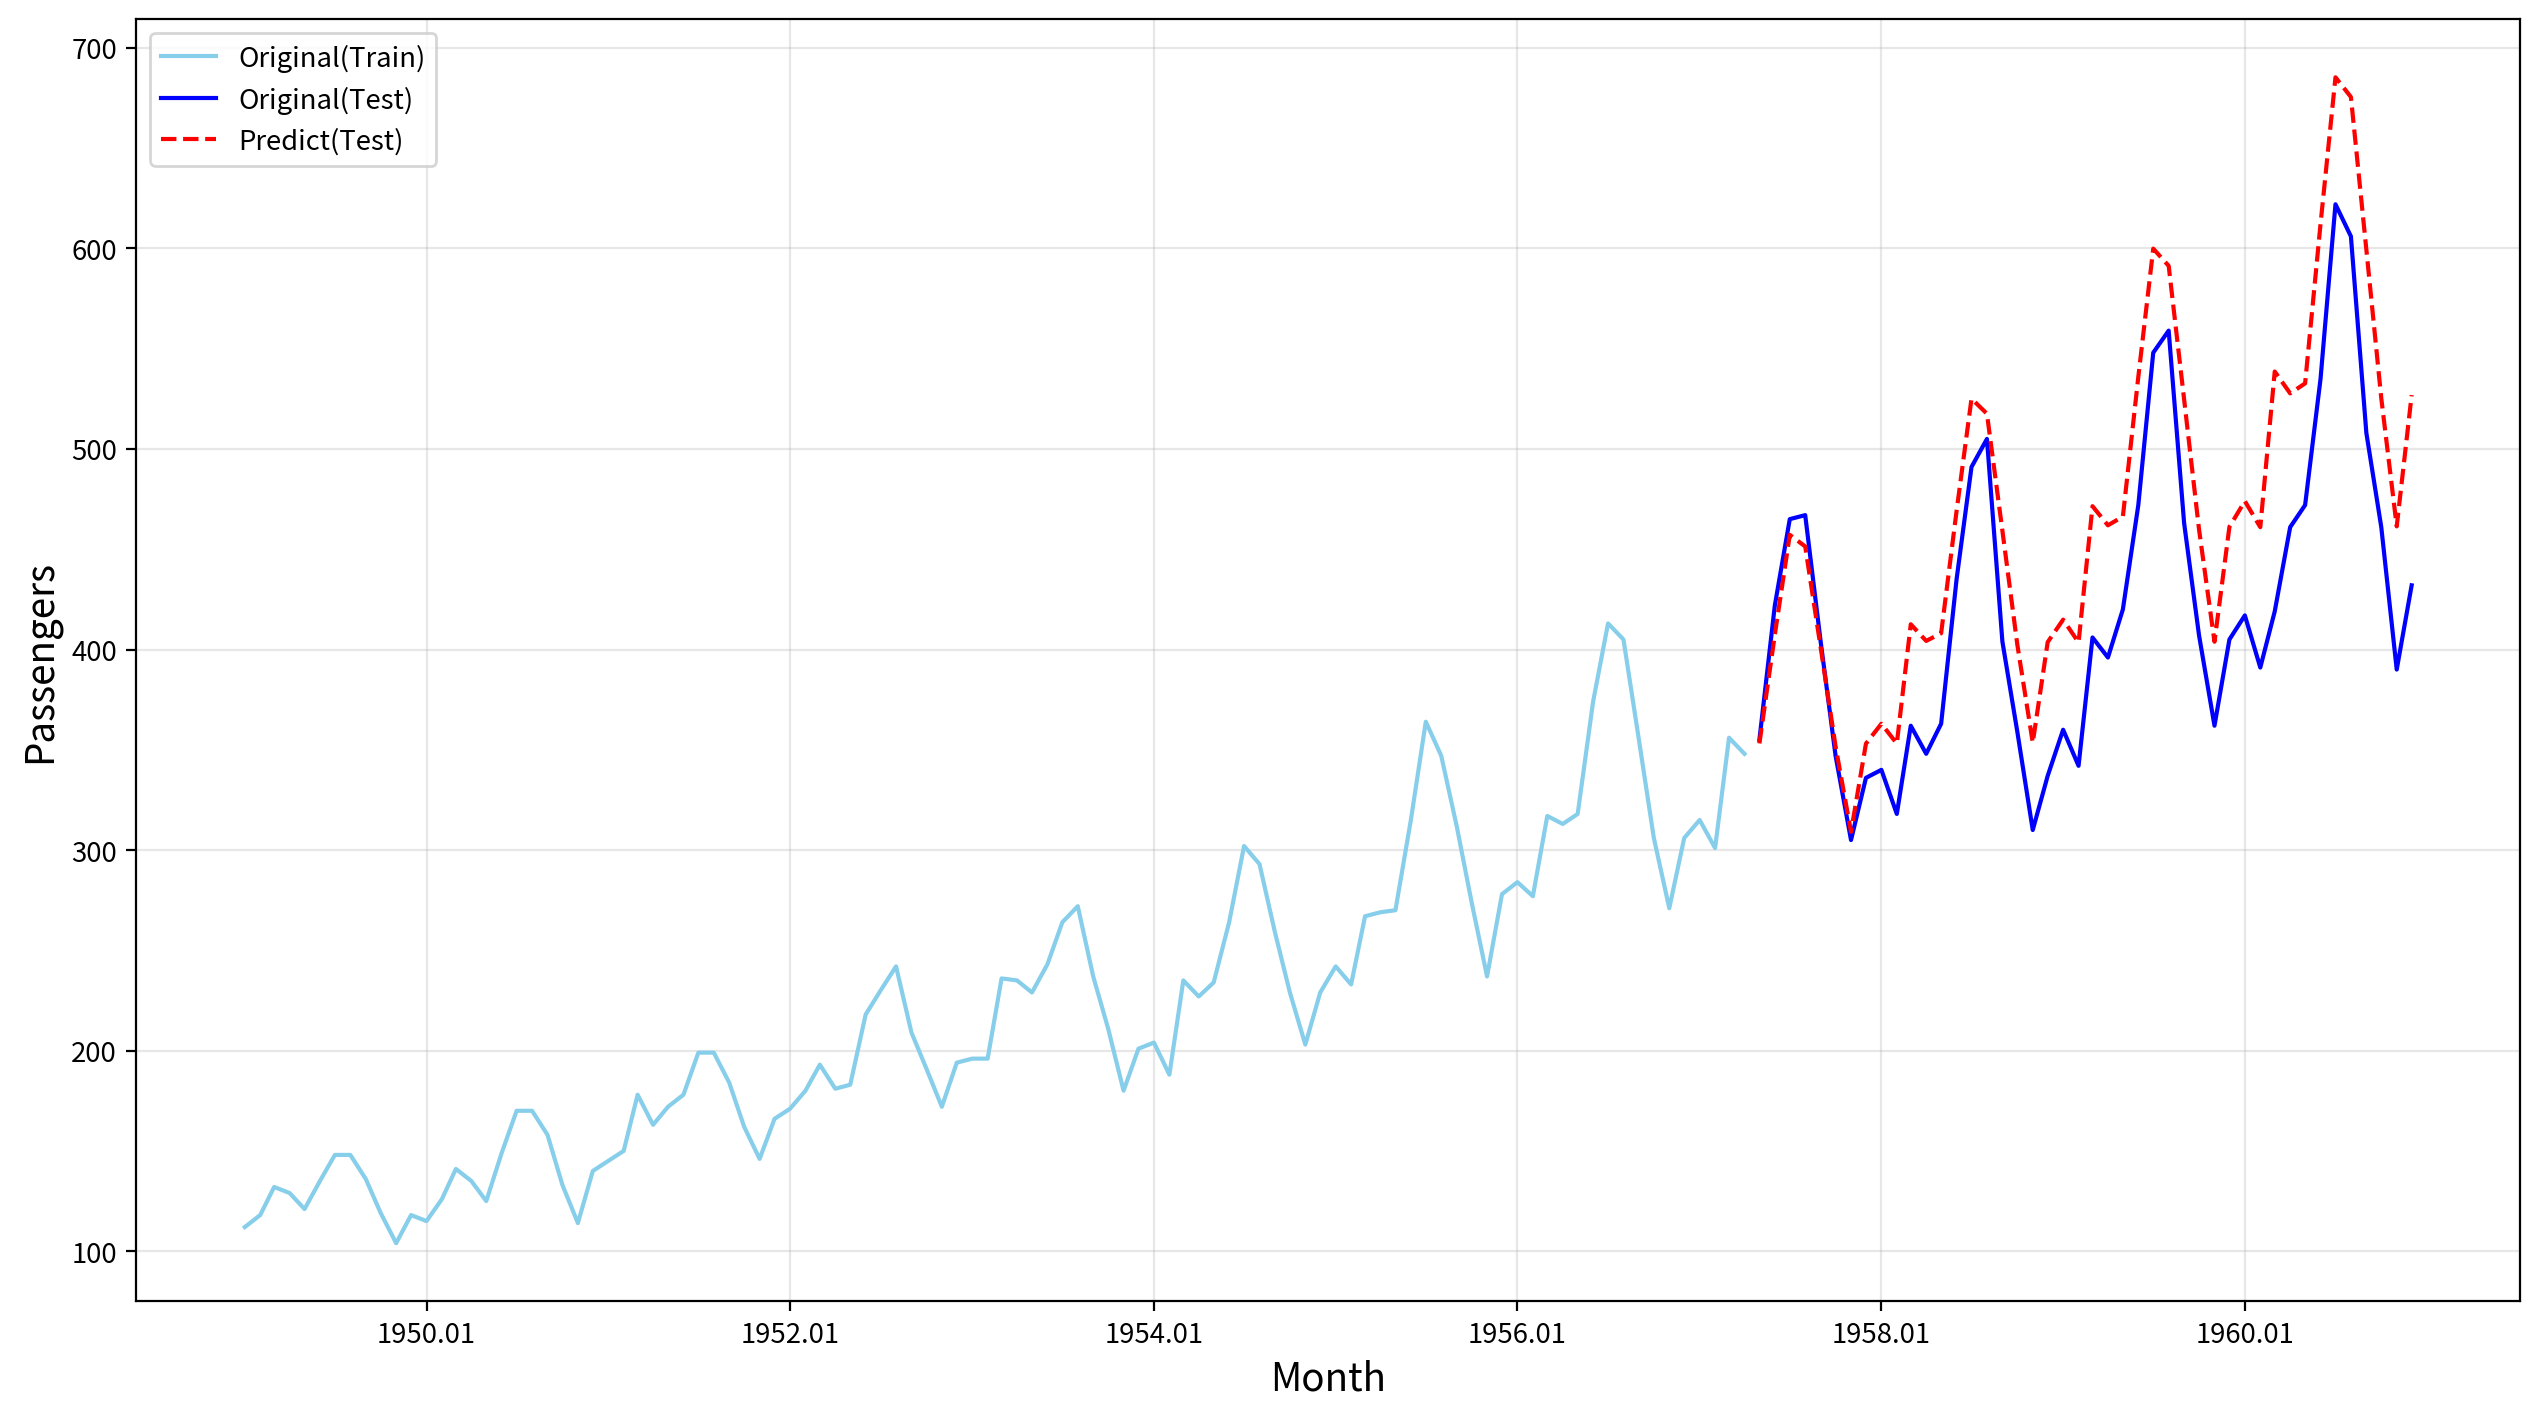

In [9]:
figsize = (1280 / 100, 720 / 100)
fig, ax = plt.subplots(1, 1, figsize=figsize)

# 훈련데이터 - 앞 70%의 원본 데이터
sb.lineplot(
    data=train, x=train.index, y="Passengers", label="Original(Train)", color="skyblue"
)

# 검증데이터 - 뒤 30%의 원본 데이터
sb.lineplot(
    data=test, x=test.index, y="Passengers", label="Original(Test)", color="blue"
)

# 예측치 - 뒤 30%에 대한 예측 데이터
sb.lineplot(
    x=preds.index, y=preds.values, label="Predict(Test)", linestyle="--", color="red"
)

ax.grid(True, alpha=0.3)
ax.set_xlabel("Month")
ax.set_ylabel("Passengers")

# 그래프의 x축이 날짜로 구성되어 있을 경우 형식 지정
monthyearFmt = dates.DateFormatter("%Y.%m")
ax.xaxis.set_major_formatter(monthyearFmt)

plt.tight_layout()
plt.show()
plt.close()

## #05. 성능평가 - 잔차 플롯 검토

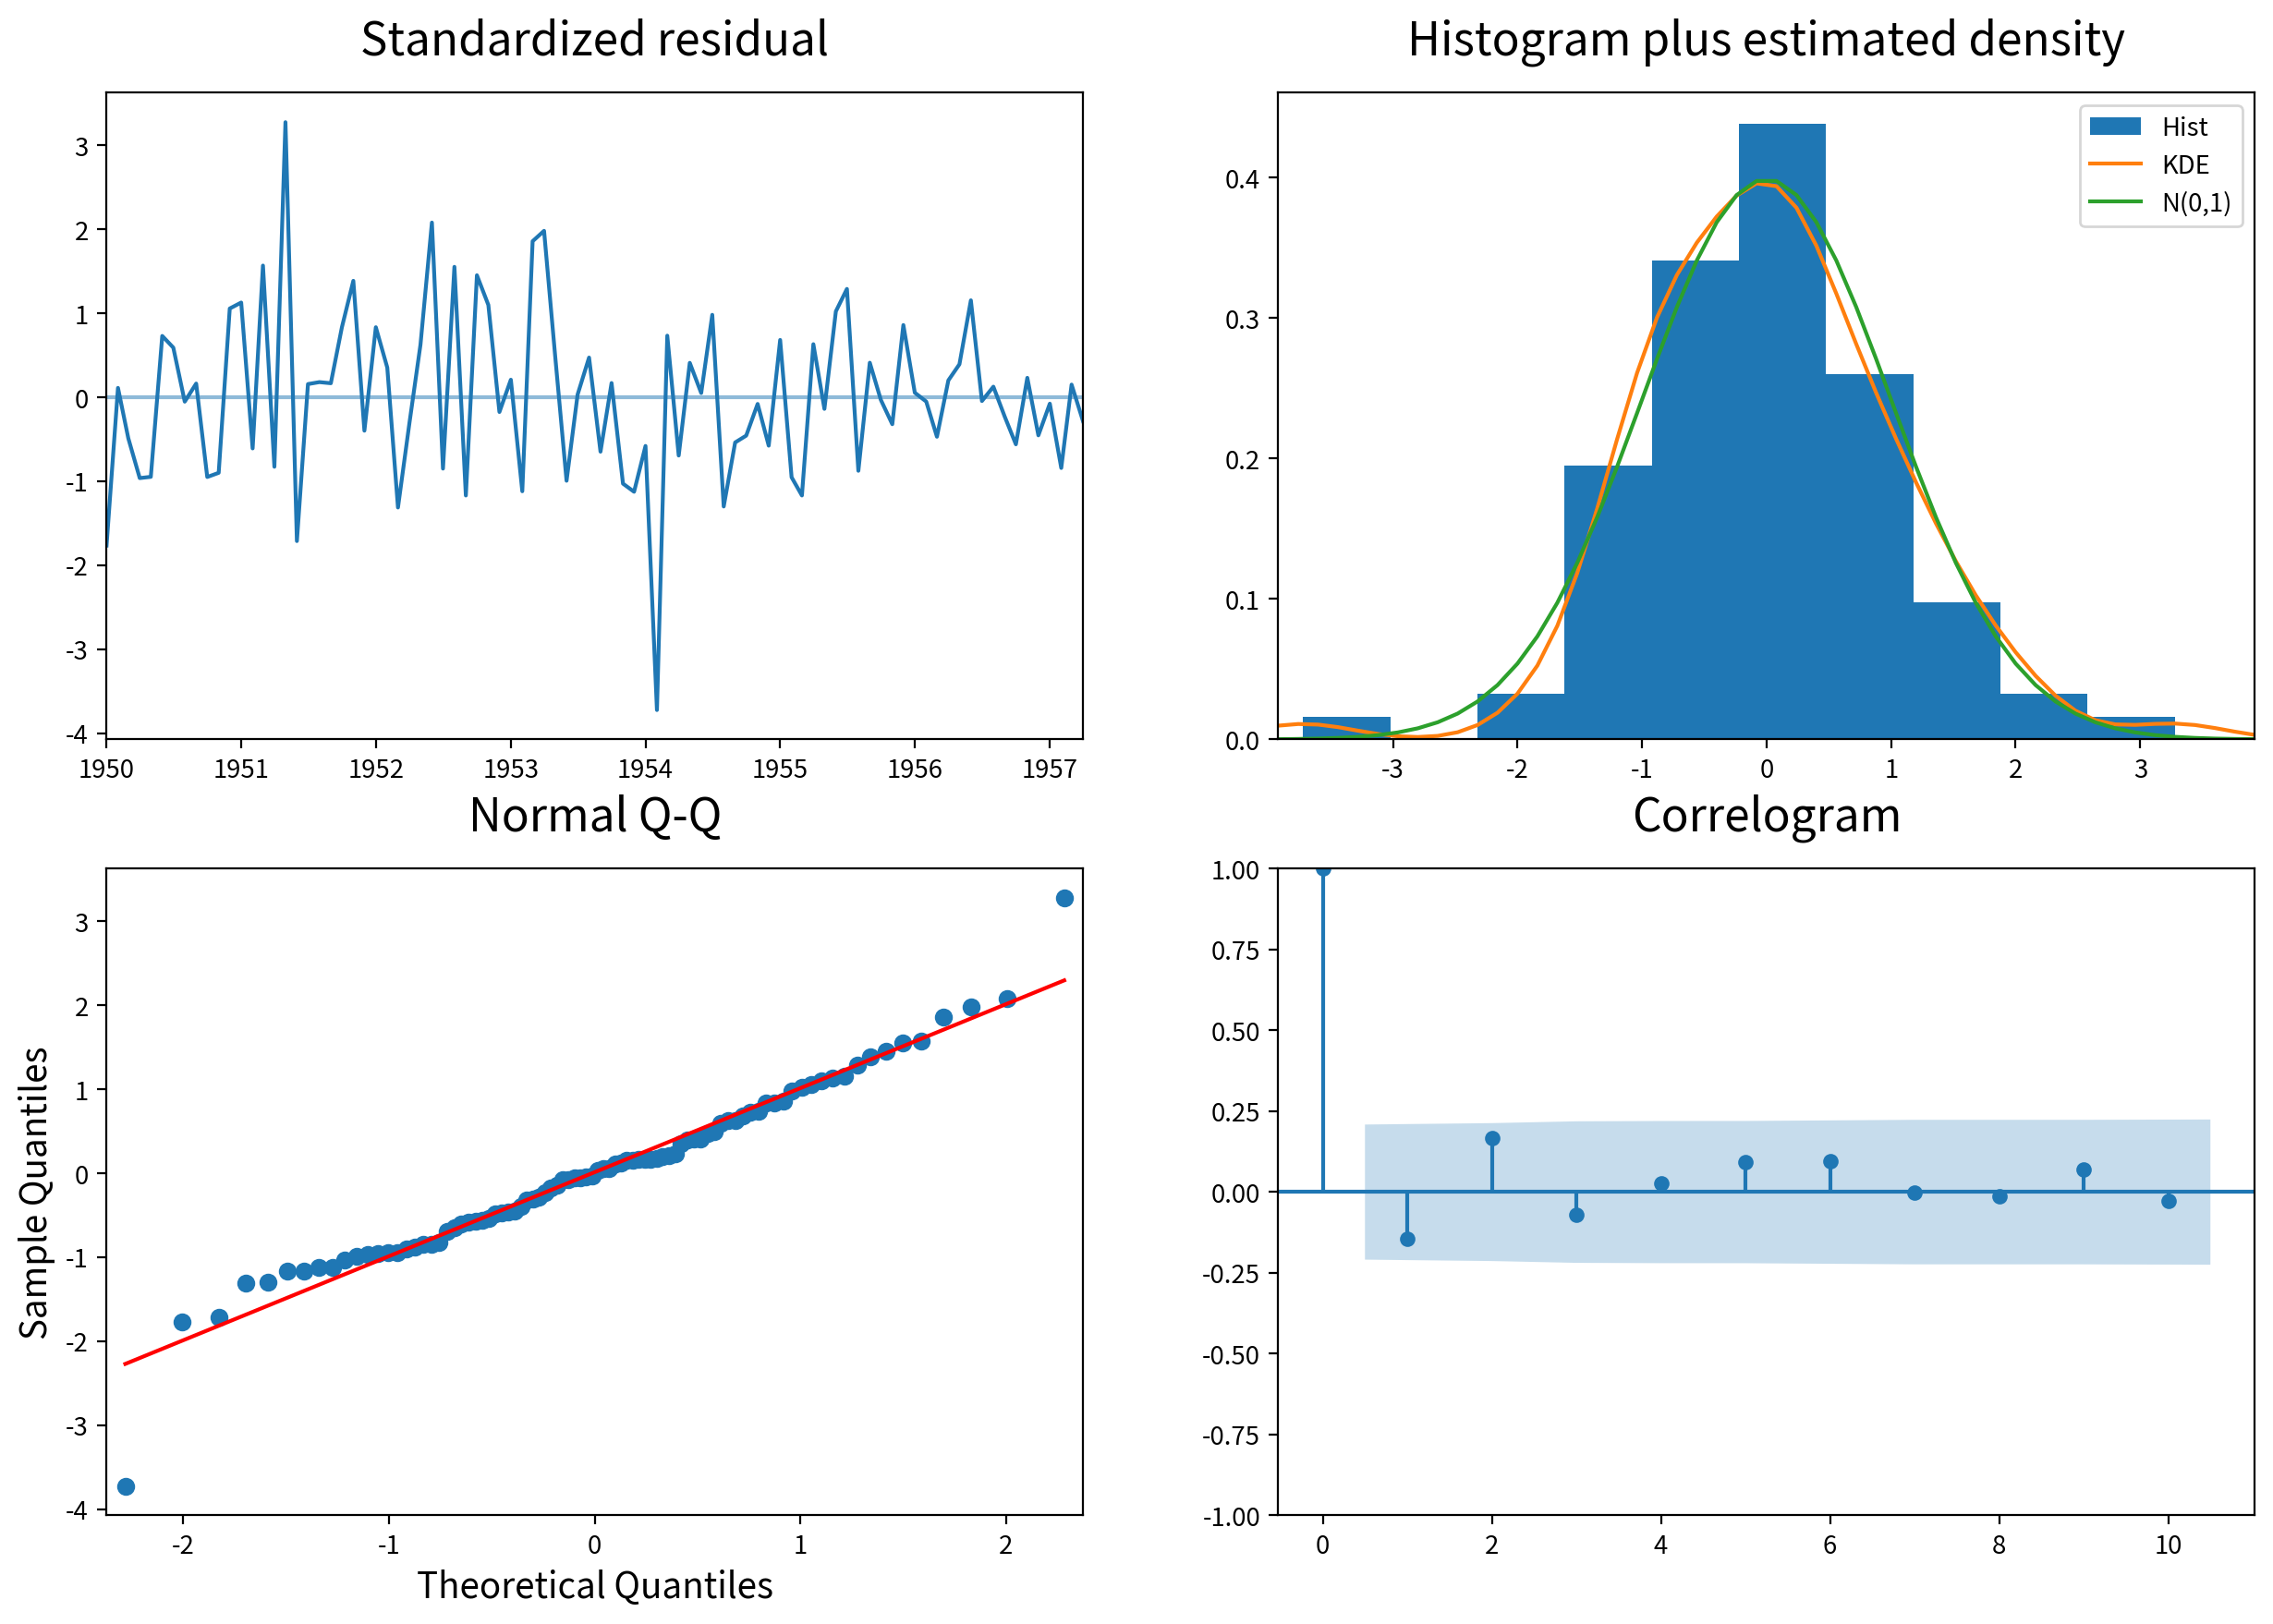

In [10]:
model.plot_diagnostics(figsize=(15, 10))
plt.show()
plt.close()

### 💡 인사이트

- **잔차 평균**: 표준화 잔차가 0 주변에 머무르며 뚜렷한 편향은 보이지 않음
- **정규성**: 히스토그램과 KDE가 정규분포 곡선과 유사하며, 대체로 정규성 가정에 부합함
- **QQ-plot**: 대부분 직선에 근접하지만 양끝단에서 이탈이 있어 극단값이 존재함
- **이상치**: 표준화 잔차에서 큰 음의 급락이 관찰되어 특정 시점의 이상치 가능성 있음
- **자기상관**: ACF가 신뢰구간 내에 있어 잔차의 자기상관이 거의 없음 (백색잡음에 가까움)